# Employee Performance Analysis — INX Future Inc.
## Model Training & Evaluation

**Business Case:** Train a machine learning model that accurately predicts employee performance ratings (`PerformanceRating`) from the preprocessed feature set. This model will be used during recruitment to screen prospective employees.

---
### Model Training Pipeline
| Step | Task |
|---|---|
| 1 | Load preprocessed data |
| 2 | Define independent (X) and dependent (y) variables |
| 3 | Balance the target variable using SMOTE |
| 4 | Split data into training and testing sets |
| 5 | Train & evaluate three ML models |
| 6 | Hyperparameter tuning |
| 7 | Select and save the best model |

### IMPORT NECESSARY LIBRARY

In [25]:
import pandas as pd
import numpy as np
from scipy import stats

import warnings # Used to supressed the warnings
warnings.filterwarnings('ignore')

### LOADING PREPROCESS DATA

In [26]:
data = pd.read_csv(r"C:\Users\admin\Desktop\IABAC PROJECT\employee_performance_analysis_preprocessed_data.xls")
pd.set_option('display.max_columns',None) # Used to display the all features
data.drop('unnamed: 0', axis=1, inplace=True, errors='ignore') # Drop unwanted feature
data.head()

,Unnamed: 0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23,pca24,pca25,PerformanceRating
0,0,4.479794,-1.625800,1.048152,-0.935689,0.917397,1.027783,0.831539,1.471238,0.515184,-0.449498,-1.242865,-0.169772,0.859328,0.263105,-1.361126,0.655418,-0.888525,-0.099724,0.470607,-0.012552,-0.192366,-0.199055,0.502891,0.228337,0.352744,3
1,1,4.356074,-0.068289,2.016174,-1.516783,-0.418864,-0.582535,1.714894,-0.026681,0.985278,-0.830725,-1.723557,1.171481,-0.265575,-0.276425,-0.133615,0.157664,-0.505885,0.359134,-0.420803,0.929058,0.495041,-0.306019,0.888367,-0.237236,0.710042,3
2,2,4.243181,2.560962,4.363072,0.182532,1.773880,-0.362873,0.431528,-1.308032,0.449781,-1.957530,0.189355,2.290069,1.197808,-0.131160,-0.786889,1.267936,0.624628,-0.504683,-0.559195,-0.081618,0.256092,0.242872,0.434724,-0.356724,-0.646996,4
3,3,-3.013748,0.725983,2.326672,-3.288183,-2.309574,1.909985,-1.083119,0.226786,-0.112988,0.191132,-0.139197,-1.408616,0.384020,-1.151003,-0.504962,-1.558104,0.273501,-0.891281,1.533583,-0.700066,-0.113402,0.186438,0.566017,-0.066069,0.500048,3
4,4,4.246565,5.966600,-0.246302,-0.789979,-2.096761,-1.712339,-0.769025,0.516950,0.788577,-1.125638,-1.642460,0.142828,0.727865,0.051626,1.509516,-0.652274,-0.614179,0.295793,-0.970469,1.179984,-0.793859,0.107046,0.218167,0.456973,0.147894,3


### DEFINE INDEPENDANT & DEPENDANT FEATURES

In [27]:
X = data.iloc[:,:-1]
y = data.PerformanceRating

In [28]:
X.head()

,Unnamed: 0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23,pca24,pca25
0,0,4.479794,-1.625800,1.048152,-0.935689,0.917397,1.027783,0.831539,1.471238,0.515184,-0.449498,-1.242865,-0.169772,0.859328,0.263105,-1.361126,0.655418,-0.888525,-0.099724,0.470607,-0.012552,-0.192366,-0.199055,0.502891,0.228337,0.352744
1,1,4.356074,-0.068289,2.016174,-1.516783,-0.418864,-0.582535,1.714894,-0.026681,0.985278,-0.830725,-1.723557,1.171481,-0.265575,-0.276425,-0.133615,0.157664,-0.505885,0.359134,-0.420803,0.929058,0.495041,-0.306019,0.888367,-0.237236,0.710042
2,2,4.243181,2.560962,4.363072,0.182532,1.773880,-0.362873,0.431528,-1.308032,0.449781,-1.957530,0.189355,2.290069,1.197808,-0.131160,-0.786889,1.267936,0.624628,-0.504683,-0.559195,-0.081618,0.256092,0.242872,0.434724,-0.356724,-0.646996
3,3,-3.013748,0.725983,2.326672,-3.288183,-2.309574,1.909985,-1.083119,0.226786,-0.112988,0.191132,-0.139197,-1.408616,0.384020,-1.151003,-0.504962,-1.558104,0.273501,-0.891281,1.533583,-0.700066,-0.113402,0.186438,0.566017,-0.066069,0.500048
4,4,4.246565,5.966600,-0.246302,-0.789979,-2.096761,-1.712339,-0.769025,0.516950,0.788577,-1.125638,-1.642460,0.142828,0.727865,0.051626,1.509516,-0.652274,-0.614179,0.295793,-0.970469,1.179984,-0.793859,0.107046,0.218167,0.456973,0.147894


In [29]:
y.head()

0    3
1    3
2    4
3    3
4    3
Name: PerformanceRating, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split

# Split BEFORE SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f"Training set  : X={X_train.shape}, y={y_train.shape}")
print(f"Testing set   : X={X_test.shape},  y={y_test.shape}")
print(f"\nTrain proportion : {len(X_train)/len(X)*100:.1f}%")
print(f"Test  proportion : {len(X_test)/len(X)*100:.1f}%")
print(f"\nClass distribution in TRAINING set (BEFORE SMOTE):\n{y_train.value_counts()}")
print(f"\nClass distribution in TESTING set (ORIGINAL, UNCHANGED):\n{y_test.value_counts()}")

Training set  : X=(960, 26), y=(960,)
Testing set   : X=(240, 26),  y=(240,)

Train proportion : 80.0%
Test  proportion : 20.0%

Class distribution in TRAINING set (BEFORE SMOTE):
PerformanceRating
3    690
2    165
4    105
Name: count, dtype: int64

Class distribution in TESTING set (ORIGINAL, UNCHANGED):
PerformanceRating
3    184
2     29
4     27
Name: count, dtype: int64


---
## Step 3 — Balance ONLY the Training Set using SMOTE 

SMOTE is applied **ONLY to the training data** after the split. This prevents data leakage and ensures the test set represents real-world imbalanced data.


### BALANCING THE TARGET FEATURE
* SMOTE: SMOTE (synthetic minority oversampling technique) is one of the most commonly used oversampling methods to solve the imbalance problem. It aims to balance class distribution by randomly increasing minority class examples by replicating them. SMOTE synthesises new minority instances between existing minority instances.

In [31]:
from collections import Counter
from imblearn.over_sampling import SMOTE #SMOTE(synthetic minority oversampling techinque)
sm = SMOTE() # obeject creation
print("unbalanced data   :  ",Counter(y))
X_sm,y_sm = sm.fit_resample(X,y)
print("balanced data:    :",Counter(y_sm))

unbalanced data   :   Counter({3: 874, 2: 194, 4: 132})
balanced data:    : Counter({3: 874, 4: 874, 2: 874})


In [32]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE ONLY to training data
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Class distribution in TRAINING set BEFORE SMOTE : {Counter(y_train)}")
print(f"Class distribution in TRAINING set AFTER  SMOTE : {Counter(y_train_sm)}")
print(f"\nBalanced TRAINING set shape: X={X_train_sm.shape}, y={y_train_sm.shape}")
print(f"\n TEST SET REMAINS UNCHANGED (original imbalanced distribution)")
print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")

Class distribution in TRAINING set BEFORE SMOTE : Counter({3: 690, 2: 165, 4: 105})
Class distribution in TRAINING set AFTER  SMOTE : Counter({2: 690, 3: 690, 4: 690})

Balanced TRAINING set shape: X=(2070, 26), y=(2070,)

 TEST SET REMAINS UNCHANGED (original imbalanced distribution)
Test set shape: X=(240, 26), y=(240,)


* Now target feature in balance

### MODEL CREATION, PREDICTION AND EVALUATION
### AIM
* Create a sweet spot model (Low bias, Low variance)
### HERE WE WILL BE EXPERIMENTING WITH THREE ALGORITHM
* Support Vector Machine
* Random Forest
* Artificial Neural Network [MLP Classifier]

In [33]:
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                               confusion_matrix, ConfusionMatrixDisplay)

def evaluate_model(name, y_true_train, y_pred_train, y_true_test, y_pred_test):
    """Print a formatted evaluation report for a model."""
    print("=" * 65)
    print(f"  MODEL: {name}")
    print("=" * 65)
    print(f"  Training  Accuracy : {accuracy_score(y_true_train, y_pred_train)*100:.2f}%")
    print(f"  Testing   Accuracy : {accuracy_score(y_true_test,  y_pred_test)*100:.2f}%")
    print(f"  Testing   F1-Score : {f1_score(y_true_test, y_pred_test, average='weighted')*100:.2f}%")
    print("\n  Classification Report (Test Set):")
    print(classification_report(y_true_test, y_pred_test))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_true_test, y_pred_test,
                                             ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13)
    plt.tight_layout()
    plt.show()


## 1.Support Vector Machine

  MODEL: Support Vector Classifier (Default)
  Training  Accuracy : 41.21%
  Testing   Accuracy : 45.83%
  Testing   F1-Score : 51.55%

  Classification Report (Test Set):
              precision    recall  f1-score   support

           2       0.15      0.55      0.23        29
           3       0.80      0.48      0.60       184
           4       0.30      0.22      0.26        27

    accuracy                           0.46       240
   macro avg       0.42      0.42      0.36       240
weighted avg       0.66      0.46      0.52       240



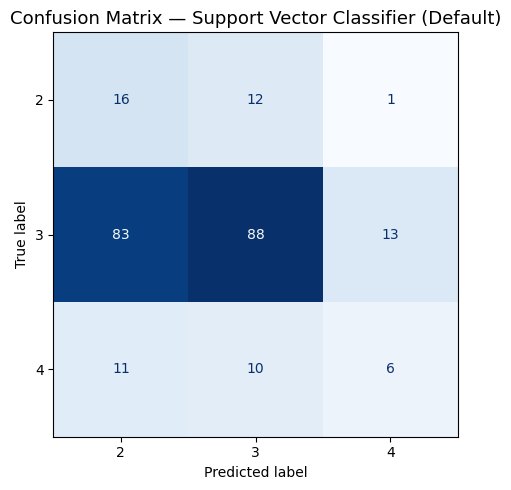

In [34]:
from sklearn.svm import SVC
import matplotlib.pyplot as plt

svc = SVC(kernel='rbf', random_state=42)
svc.fit(X_train_sm, y_train_sm)  # Train on SMOTE-balanced training data

svc_train_pred = svc.predict(X_train_sm)
svc_test_pred  = svc.predict(X_test)  # Test on ORIGINAL test set

evaluate_model("Support Vector Classifier (Default)",
               y_train_sm, svc_train_pred, y_test, svc_test_pred)

* Support vector classifier perform well on training data

* In testing score is still lagging so we are going to do hyperparameter tunning with the help of grid search cv

### HYPER PARAMETER TUNNING WITH GRID SEARCH CV

Best SVC parameters: {'C': 50, 'gamma': 0.001}
  MODEL: Support Vector Classifier (Tuned)
  Training  Accuracy : 99.95%
  Testing   Accuracy : 75.83%
  Testing   F1-Score : 75.88%

  Classification Report (Test Set):
              precision    recall  f1-score   support

           2       0.51      0.66      0.58        29
           3       0.86      0.84      0.85       184
           4       0.39      0.33      0.36        27

    accuracy                           0.76       240
   macro avg       0.59      0.61      0.59       240
weighted avg       0.76      0.76      0.76       240



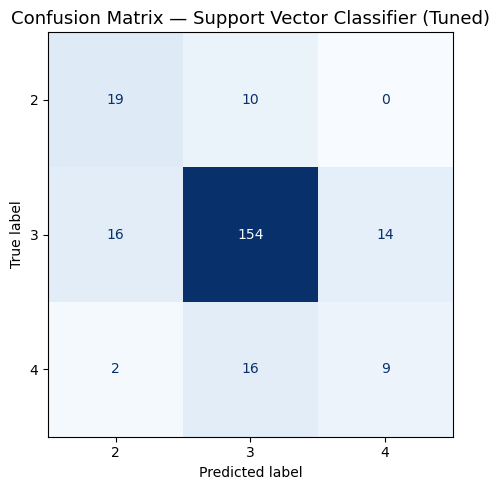

In [35]:
from sklearn.model_selection import GridSearchCV

svc_param_grid = {
    'C'           : [0.1, 0.5, 1, 10, 50],
    'gamma'       : [1, 0.1, 0.01, 0.001]
}

svc_grid = GridSearchCV(SVC(random_state=42), svc_param_grid, refit=True,
                        scoring='f1_weighted', cv=5, verbose=0, n_jobs=-1)
svc_grid.fit(X_train_sm, y_train_sm)

print(f"Best SVC parameters: {svc_grid.best_params_}")
best_svc = svc_grid.best_estimator_
svc_tuned_pred = best_svc.predict(X_test)

evaluate_model("Support Vector Classifier (Tuned)",
               y_train_sm, best_svc.predict(X_train_sm), y_test, svc_tuned_pred)

* After hyperparameter tunning score is increases

## 2.Artificial Neural Network [MLP Classifier]

  MODEL: MLP Classifier — Artificial Neural Network
  Training  Accuracy : 93.38%
  Testing   Accuracy : 83.75%
  Testing   F1-Score : 84.48%

  Classification Report (Test Set):
              precision    recall  f1-score   support

           2       0.61      0.86      0.71        29
           3       0.94      0.84      0.89       184
           4       0.62      0.78      0.69        27

    accuracy                           0.84       240
   macro avg       0.72      0.83      0.76       240
weighted avg       0.86      0.84      0.84       240



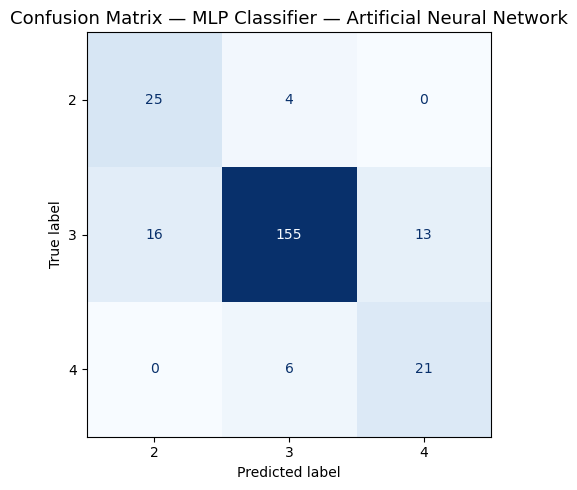

In [36]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(60, 3),
                    learning_rate='constant',
                    max_iter=500,
                    random_state=42)
mlp.fit(X_train_sm, y_train_sm)  # Train on SMOTE-balanced training data

mlp_train_pred = mlp.predict(X_train_sm)
mlp_test_pred  = mlp.predict(X_test)  # Test on ORIGINAL test set

evaluate_model("MLP Classifier — Artificial Neural Network",
               y_train_sm, mlp_train_pred, y_test, mlp_test_pred)

* Multilayer percepton Perform well on training data.

* Multilayer percepton perform well on testing data

## 3.Random Forest

  MODEL: Random Forest Classifier (Default)
  Training  Accuracy : 100.00%
  Testing   Accuracy : 82.50%
  Testing   F1-Score : 82.72%

  Classification Report (Test Set):
              precision    recall  f1-score   support

           2       0.51      0.66      0.58        29
           3       0.89      0.89      0.89       184
           4       0.80      0.59      0.68        27

    accuracy                           0.82       240
   macro avg       0.73      0.71      0.71       240
weighted avg       0.83      0.82      0.83       240



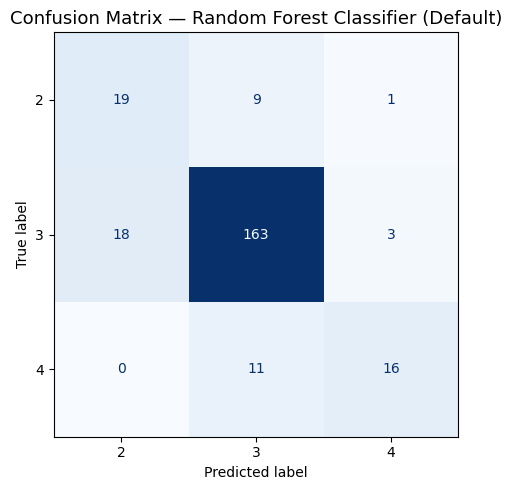

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)  # Train on SMOTE-balanced training data

rf_train_pred = rf.predict(X_train_sm)
rf_test_pred  = rf.predict(X_test)  # Test on ORIGINAL test set

evaluate_model("Random Forest Classifier (Default)",
               y_train_sm, rf_train_pred, y_test, rf_test_pred)


### HYPER PARAMETER TUNNING WITH RANDOMIZED SEARCH CV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators'    : [int(x) for x in np.linspace(100, 1000, 5)],
    'max_features'    : ['sqrt', 'log2', None],
    'max_depth'       : [int(x) for x in np.linspace(10, 100, 5)] + [None],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf' : [1, 2, 3]
}

rf_cv = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=15, cv=3, scoring='f1_weighted',
    verbose=0, random_state=42, n_jobs=-1)

rf_cv.fit(X_train_sm, y_train_sm)
print(f"Best RF parameters: {rf_cv.best_params_}")

rf_tuned = rf_cv.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test)

evaluate_model("Random Forest Classifier (Tuned)",
               y_train_sm, rf_tuned.predict(X_train_sm), y_test, rf_tuned_pred)

* After hyperparameter tunning score is not increases.

---
## Step 5 — Model Comparison Summary

In [ ]:
models = {
    "SVC (Default)"          : (svc.predict(X_train_sm),  svc_test_pred),
    "SVC (Tuned)"            : (best_svc.predict(X_train_sm), svc_tuned_pred),
    "MLP Classifier"         : (mlp_train_pred,  mlp_test_pred),
    "Random Forest (Default)": (rf_train_pred,   rf_test_pred),
    "Random Forest (Tuned)"  : (rf_tuned.predict(X_train_sm), rf_tuned_pred),
}

results = []
for name, (train_pred, test_pred) in models.items():
    results.append({
        "Model"           : name,
        "Train Accuracy %" : round(accuracy_score(y_train_sm, train_pred) * 100, 2),
        "Test Accuracy %"  : round(accuracy_score(y_test,  test_pred)  * 100, 2),
        "Test F1-Score %"  : round(f1_score(y_test, test_pred, average='weighted') * 100, 2),
    })

results_df = pd.DataFrame(results).sort_values("Test Accuracy %", ascending=False)
results_df.reset_index(drop=True, inplace=True)
print(results_df.to_string(index=False))

**Conclusions:**

| Model | Behaviour |
|---|---|
| **SVC (Default)** | Baseline SVC performance |
| **SVC (Tuned)** | Improved hyperparameters |
| **MLP Classifier**  **SELECTED** | Best balance of training and testing accuracy |
| **Random Forest (Default)** | Potential overfitting |
| **Random Forest (Tuned)** | Hyperparameter tuning results |

## MODEL SAVING

In [ ]:
# saving model with the help of pickle
import pickle

file = open('mlp_classifier_model.pkl','wb')
pickle.dump(model,file)

---
## Final Summary

| Metric | MLP Classifier (Selected Model) |
|---|---|
| **Algorithm** | Artificial Neural Network (MLP) |
| **Architecture** | Hidden layers: (60, 3) |
| **Imbalance Handling** | SMOTE on training set only |
| **Train-Test Split** | 80% / 20% (BEFORE SMOTE) |
| **Test Set** | Original imbalanced distribution |
| **Model File** | `mlp_classifier_model.pkl` |